In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/notebooks/phyothaw/06-target-and-model-dataset-ipynb/model_ready_with_missing_features_2020_2025.csv
/kaggle/input/notebooks/phyothaw/06-target-and-model-dataset-ipynb/__results__.html
/kaggle/input/notebooks/phyothaw/06-target-and-model-dataset-ipynb/__notebook__.ipynb
/kaggle/input/notebooks/phyothaw/06-target-and-model-dataset-ipynb/__output__.json
/kaggle/input/notebooks/phyothaw/06-target-and-model-dataset-ipynb/model_ready_complete_case_2020_2025.csv
/kaggle/input/notebooks/phyothaw/06-target-and-model-dataset-ipynb/custom.css


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
data_file = ("/kaggle/input/notebooks/phyothaw/06-target-and-model-dataset-ipynb/model_ready_complete_case_2020_2025.csv")
df = pd.read_csv(data_file, parse_dates=["date"])

print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (7370, 42)


,ticker,Open,High,Low,Close,Volume,Dividends,Stock Splits,SMA_50,SMA_200,...,vix_close,vix_change,market_return_lag_1,vix_close_lag_1,vix_change_lag_1,daily_return_check,future_close_5d,forward_return_5d,movement_5d,target_5d
0,BRK-B,227.050003,228.470001,226.130005,228.449997,3286700,0.0,0.0,222.4416,210.69605,...,12.32,-0.019108,-0.002855,12.56,0.001595,0.008075,228.630005,0.000788,Neutral,1
1,BRK-B,227.850006,228.389999,226.880005,227.169998,3355400,0.0,0.0,222.7334,210.82745,...,12.39,0.005682,0.006976,12.32,-0.019108,-0.005603,229.539993,0.010433,Neutral,1
2,BRK-B,226.800003,228.639999,226.779999,228.350006,2662500,0.0,0.0,222.9838,210.94420,...,12.42,0.002421,-0.001515,12.39,0.005682,0.005194,229.380005,0.004511,Neutral,1
3,BRK-B,229.339996,230.029999,228.520004,229.729996,3036400,0.0,0.0,223.2188,211.07345,...,12.32,-0.008052,0.001870,12.42,0.002421,0.006043,226.860001,-0.012493,Neutral,1
4,BRK-B,230.130005,231.610001,229.550003,230.199997,6603800,0.0,0.0,223.4052,211.20610,...,12.10,-0.017857,0.008367,12.32,-0.008052,0.002046,222.449997,-0.033666,Down,0


## Dataset Validation

The final modelling dataset is checked again to confirm that it contains
valid dates, unique ticker-date observations, complete target values, and
equal stock representation.

In [4]:
print("Invalid dates:", df["date"].isna().sum())
print("Duplicate ticker-date rows:",df.duplicated(subset=["ticker", "date"]).sum())
print("Missing target values:",df["target_5d"].isna().sum())
print("\nRows per ticker:")
print(df["ticker"].value_counts().sort_index())

Invalid dates: 0
Duplicate ticker-date rows: 0
Missing target values: 0

Rows per ticker:
ticker
BRK-B    1474
CVX      1474
GE       1474
MSFT     1474
NVDA     1474
Name: count, dtype: int64


In [5]:
date_coverage = (df.groupby("ticker")["date"].agg(start_date="min", end_date="max", observations="count"))
display(date_coverage)

,start_date,end_date,observations
ticker,,,
BRK-B,2020-01-13,2025-12-22,1474
CVX,2020-01-13,2025-12-22,1474
GE,2020-01-13,2025-12-22,1474
MSFT,2020-01-13,2025-12-22,1474
NVDA,2020-01-13,2025-12-22,1474


In [6]:
print("Overall start date:", df["date"].min())
print("Overall end date:", df["date"].max())
print("Number of unique trading dates:", df["date"].nunique())

Overall start date: 2020-01-13 00:00:00
Overall end date: 2025-12-22 00:00:00
Number of unique trading dates: 1474


## Target-Class Distribution

The target distribution is examined to identify class imbalance before
model training.

A moderate imbalance is expected because upward, neutral, and downward
five-day movements do not occur equally often.

,count,percentage
movement_5d,,
Down,2045,27.75
Neutral,2414,32.75
Up,2911,39.50


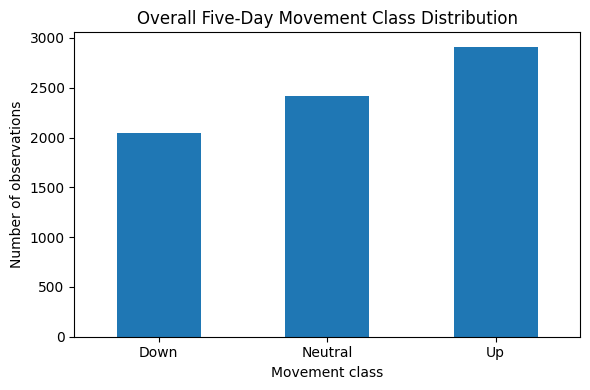

In [7]:
target_order = ["Down", "Neutral", "Up"]

target_counts = ( df["movement_5d"].value_counts().reindex(target_order))
target_percentages = ( df["movement_5d"].value_counts(normalize=True).reindex(target_order).mul(100))

target_summary = pd.DataFrame({"count": target_counts,"percentage": target_percentages}).round(2)
display(target_summary)

target_counts.plot(kind="bar",figsize=(6, 4))
plt.title("Overall Five-Day Movement Class Distribution")
plt.xlabel("Movement class")
plt.ylabel("Number of observations")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [8]:
# Count each target class for every ticker.
target_counts_by_ticker = pd.crosstab(df["ticker"], df["movement_5d"]).reindex(columns=target_order,fill_value=0)
display(target_counts_by_ticker)

movement_5d,Down,Neutral,Up
ticker,,,
BRK-B,321,699,454
CVX,405,543,526
GE,432,394,648
MSFT,402,503,569
NVDA,485,275,714


In [9]:
# Convert class counts into within-ticker percentages.

target_percentages_by_ticker = (
    pd.crosstab(
        df["ticker"],
        df["movement_5d"],
        normalize="index"
    ).reindex(columns=target_order,fill_value=0).mul(100).round(2))

display(target_percentages_by_ticker)

movement_5d,Down,Neutral,Up
ticker,,,
BRK-B,21.78,47.42,30.80
CVX,27.48,36.84,35.69
GE,29.31,26.73,43.96
MSFT,27.27,34.12,38.60
NVDA,32.90,18.66,48.44


In [10]:
target_summary_by_ticker = pd.concat({"count": target_counts_by_ticker, "percentage": target_percentages_by_ticker},axis=1)
display(target_summary_by_ticker)

count              percentage               
movement_5d  Down Neutral   Up       Down Neutral     Up
ticker                                                  
BRK-B         321     699  454      21.78   47.42  30.80
CVX           405     543  526      27.48   36.84  35.69
GE            432     394  648      29.31   26.73  43.96
MSFT          402     503  569      27.27   34.12  38.60
NVDA          485     275  714      32.90   18.66  48.44

movement_5d,Down,Neutral,Up
ticker,,,
BRK-B,21.78,47.42,30.80
CVX,27.48,36.84,35.69
GE,29.31,26.73,43.96
MSFT,27.27,34.12,38.60
NVDA,32.90,18.66,48.44


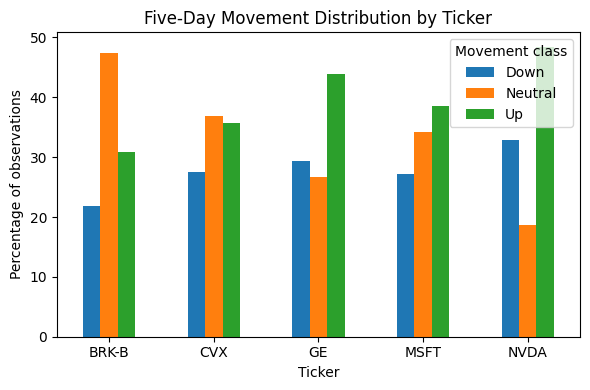

In [11]:
target_by_ticker = pd.crosstab(df["ticker"],df["movement_5d"],normalize="index").mul(100)
target_by_ticker = target_by_ticker.reindex(columns=target_order)
display(target_by_ticker.round(2))

target_by_ticker.plot(kind="bar",figsize=(6, 4))

plt.title("Five-Day Movement Distribution by Ticker")
plt.xlabel("Ticker")
plt.ylabel("Percentage of observations")
plt.xticks(rotation=0)
plt.legend(title="Movement class")
plt.tight_layout()
plt.show()

In [12]:
forward_return_summary = (
    df["forward_return_5d"]
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
            0.99
        ]
    )
)

display(forward_return_summary)

count    7370.000000
mean        0.006163
std         0.048886
min        -0.336987
1%         -0.135939
5%         -0.068739
25%        -0.018383
50%         0.005573
75%         0.030247
95%         0.084110
99%         0.142810
max         0.330894
Name: forward_return_5d, dtype: float64

In [13]:
forward_return_summary_percentage = (
    forward_return_summary * 100
)

display(
    forward_return_summary_percentage
    .to_frame(
        name="forward_return_5d_percentage"
    )
    .round(2)
)

,forward_return_5d_percentage
count,737000.00
mean,0.62
std,4.89
min,-33.70
1%,-13.59
5%,-6.87
25%,-1.84
50%,0.56
75%,3.02
95%,8.41


In [14]:
return_summary_by_ticker = (
    df.groupby("ticker")["forward_return_5d"]
    .agg(
        observations="count",
        mean="mean",
        median="median",
        standard_deviation="std",
        minimum="min",
        maximum="max"))

percentage_columns = ["mean","median","standard_deviation","minimum","maximum"]

return_summary_by_ticker[percentage_columns] = (return_summary_by_ticker[percentage_columns] * 100)
display(return_summary_by_ticker.round(2))

,observations,mean,median,standard_deviation,minimum,maximum
ticker,,,,,,
BRK-B,1474,0.32,0.38,2.77,-15.79,12.98
CVX,1474,0.29,0.32,4.60,-33.70,33.09
GE,1474,0.68,0.82,5.22,-28.20,29.13
MSFT,1474,0.44,0.56,3.63,-16.36,17.83
NVDA,1474,1.36,1.23,7.04,-22.20,30.23


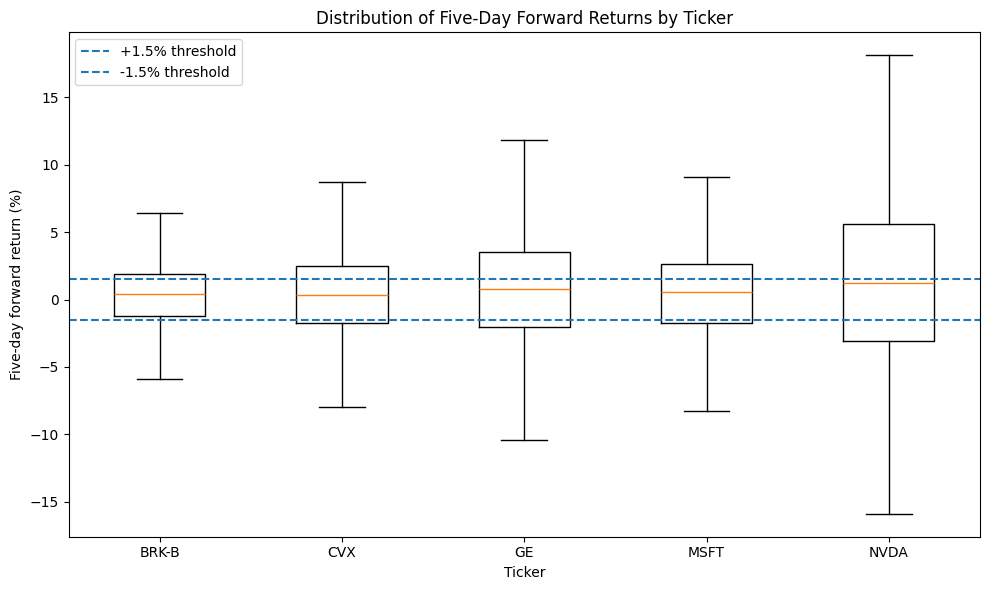

In [15]:
ticker_order = ["BRK-B","CVX","GE","MSFT","NVDA"]
boxplot_data = [df.loc[df["ticker"] == ticker,"forward_return_5d"] * 100 for ticker in ticker_order]

plt.figure(figsize=(10, 6))
plt.boxplot(boxplot_data,tick_labels=ticker_order,showfliers=False)

plt.axhline(y=1.5,linestyle="--",label="+1.5% threshold")
plt.axhline(y=-1.5,linestyle="--",label="-1.5% threshold")
plt.title("Distribution of Five-Day Forward Returns by Ticker")
plt.xlabel("Ticker")
plt.ylabel("Five-day forward return (%)")

plt.legend()
plt.tight_layout()
plt.show()

In [16]:
distribution_statistics = (df.groupby("ticker")["forward_return_5d"].agg(mean="mean",median="median",standard_deviation="std",skewness="skew"))
distribution_statistics[["mean","median","standard_deviation"]
] = (
    distribution_statistics[
        [
            "mean",
            "median",
            "standard_deviation"
        ]] * 100)

display(distribution_statistics.round(3))

,mean,median,standard_deviation,skewness
ticker,,,,
BRK-B,0.318,0.381,2.768,-0.413
CVX,0.285,0.321,4.598,-0.117
GE,0.679,0.817,5.223,-0.313
MSFT,0.440,0.560,3.627,-0.135
NVDA,1.359,1.234,7.038,0.065


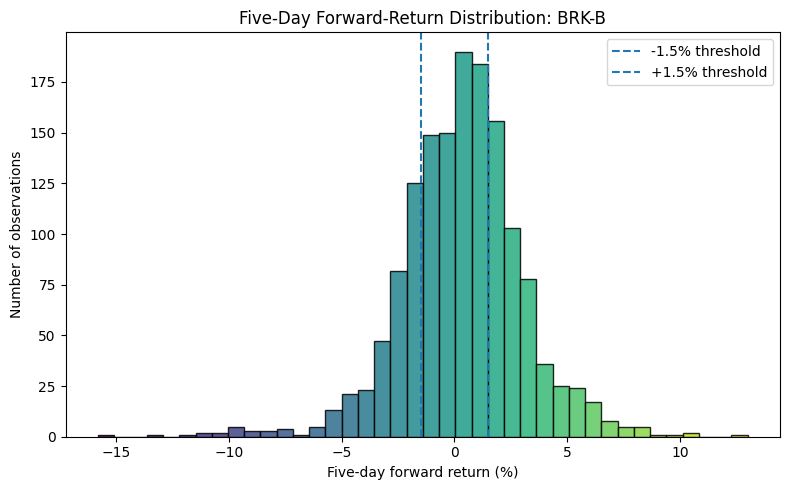

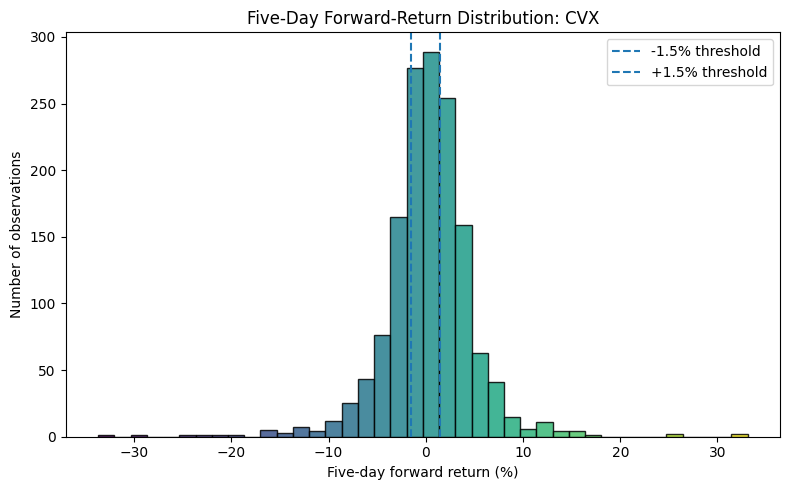

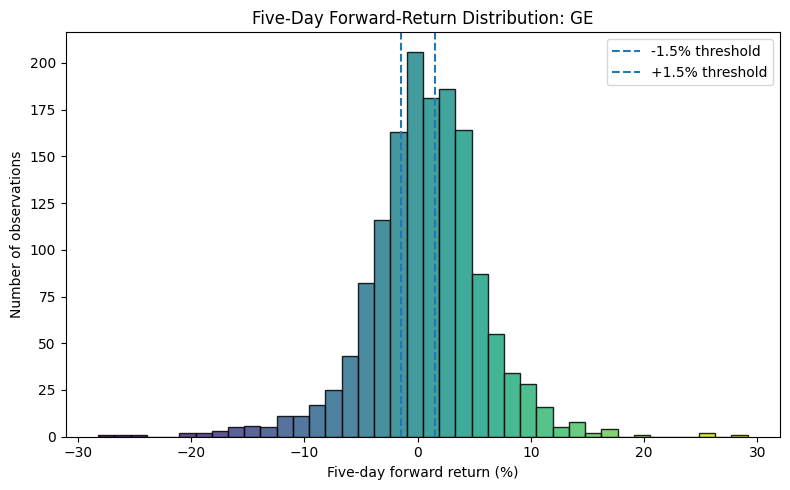

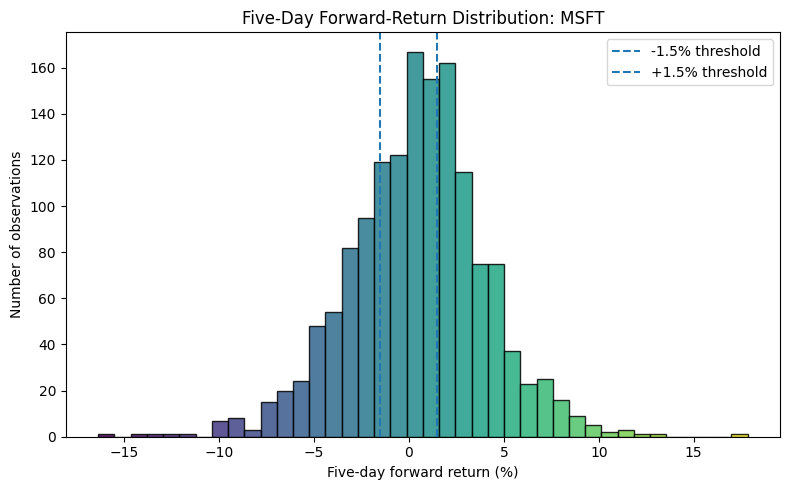

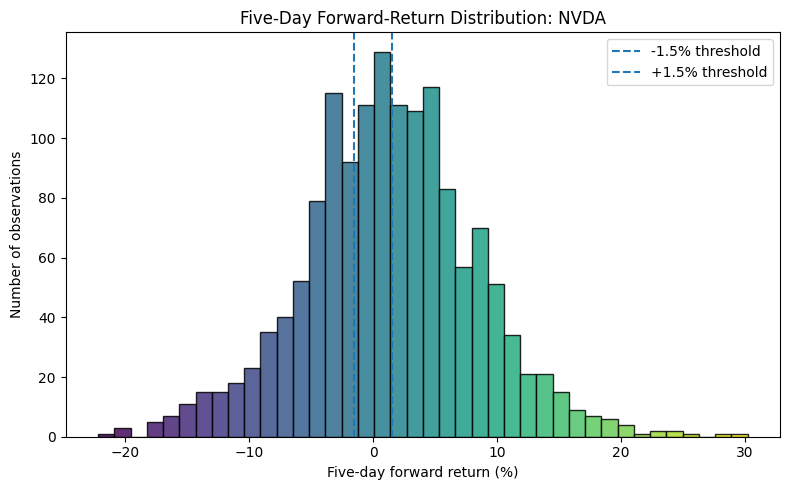

In [17]:
for ticker in ticker_order:
    ticker_returns = df.loc[df["ticker"] == ticker, "forward_return_5d"] * 100

    plt.figure(figsize=(8, 5))
    counts, bins, patches = plt.hist(ticker_returns, bins=40, edgecolor="black", alpha=0.85)

    cmap = plt.colormaps["viridis"]
    for index, patch in enumerate(patches):
        patch.set_facecolor(cmap(index / len(patches)))

    plt.axvline(-1.5, linestyle="--", label="-1.5% threshold")
    plt.axvline(1.5, linestyle="--", label="+1.5% threshold")
    plt.title(f"Five-Day Forward-Return Distribution: {ticker}")
    plt.xlabel("Five-day forward return (%)")
    plt.ylabel("Number of observations")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [18]:
technical_features = [
    "Open", "High", "Low", "Close", "Volume",
    "SMA_50", "SMA_200", "EMA_50", "EMA_200",
    "RSI", "MACD", "MACD_Signal", "MACD_Hist",
    "BB_Upper", "BB_Middle", "BB_Lower",
    "ATR", "ADX"
]

gdelt_features = [
    "gdelt_tone_lag_1", "gdelt_tone_mean_3", "gdelt_tone_mean_5",
    "gdelt_tone_std_5", "gdelt_tone_change_1d",
    "gdelt_abnormal_tone_20", "gdelt_tone_missing"
]

market_features = [
    "market_return_lag_1",
    "vix_close_lag_1",
    "vix_change_lag_1"
]

all_model_features = technical_features + gdelt_features + market_features

print("Technical features:", len(technical_features))
print("GDELT features:", len(gdelt_features))
print("Market features:", len(market_features))
print("Total features:", len(all_model_features))

Technical features: 18
GDELT features: 7
Market features: 3
Total features: 28


In [19]:
missing_columns = [col for col in all_model_features if col not in df.columns]
print("Missing columns:", missing_columns)

Missing columns: []


In [20]:
feature_summary = df[all_model_features].describe().T
display(feature_summary)

,count,mean,std,min,25%,50%,75%,max
Open,7370.0,1.858165e+02,1.387774e+02,4.977161,6.532399e+01,1.483778e+02,2.848064e+02,5.508301e+02
High,7370.0,1.876005e+02,1.396817e+02,5.221914,6.611604e+01,1.496929e+02,2.865471e+02,5.510484e+02
Low,7370.0,1.839131e+02,1.377512e+02,4.494120,6.419885e+01,1.469967e+02,2.824402e+02,5.373667e+02
Close,7370.0,1.858168e+02,1.387575e+02,4.885130,6.535356e+01,1.483130e+02,2.849116e+02,5.398000e+02
Volume,7370.0,9.330574e+07,1.826508e+08,67200.000000,5.908550e+06,1.196399e+07,3.307658e+07,1.543911e+09
SMA_50,7370.0,1.823603e+02,1.367819e+02,5.499172,6.412513e+01,1.451977e+02,2.821053e+02,5.198382e+02
SMA_200,7370.0,1.714017e+02,1.301356e+02,4.548101,6.165912e+01,1.411067e+02,2.674162e+02,4.982684e+02
EMA_50,7370.0,1.823136e+02,1.366219e+02,5.528418,6.400520e+01,1.452114e+02,2.820471e+02,5.140824e+02
EMA_200,7370.0,1.719564e+02,1.299734e+02,4.835166,6.022827e+01,1.407800e+02,2.687493e+02,4.898192e+02
RSI,7370.0,5.415851e+01,1.199135e+01,17.065470,4.561074e+01,5.410785e+01,6.267052e+01,8.994319e+01


## Feature Distribution and Correlation Analysis

The selected model features are examined for unusual ranges, skewed
distributions, and strong correlations.

This helps identify potential scaling needs and highly similar technical
indicators before model training.

In [21]:
feature_skewness = df[all_model_features].skew().sort_values(ascending=False)
display(feature_skewness.to_frame("skewness"))

,skewness
gdelt_tone_missing,27.097975
vix_close_lag_1,2.623123
Volume,2.450106
vix_change_lag_1,2.159928
gdelt_tone_std_5,1.814214
ADX,0.864438
ATR,0.764332
BB_Lower,0.711604
SMA_200,0.708971
EMA_200,0.702993


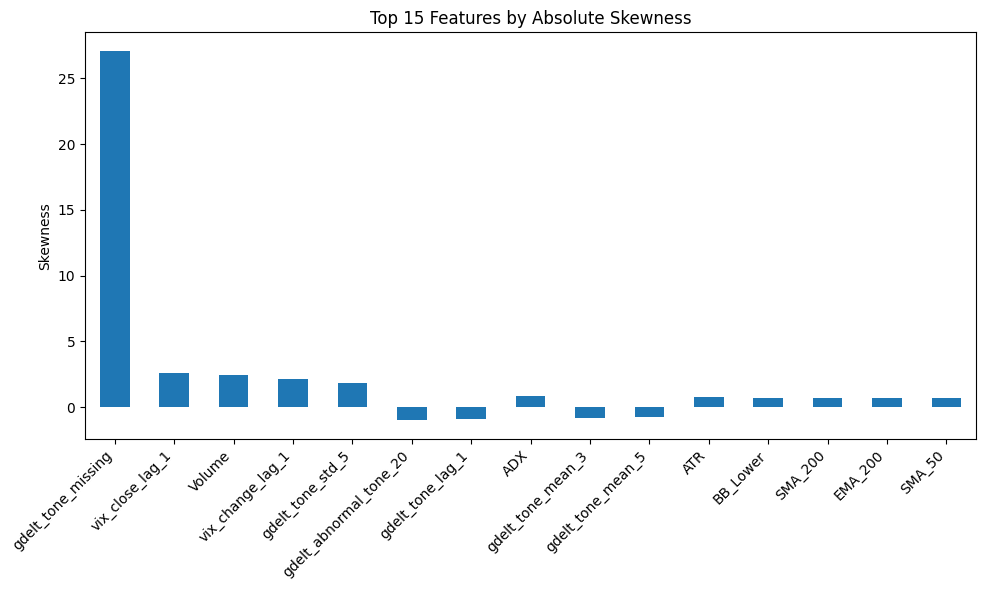

In [22]:
skew_plot = feature_skewness.reindex(feature_skewness.abs().sort_values(ascending=False).index)

plt.figure(figsize=(10, 6))
skew_plot.head(15).plot(kind="bar")

plt.ylabel("Skewness")
plt.title("Top 15 Features by Absolute Skewness")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

### Observations

Most continuous features showed low to moderate skewness, indicating reasonably balanced distributions. Volatility-related variables (e.g., VIX and trading volume) were more positively skewed, reflecting occasional periods of market stress.

The `gdelt_tone_missing` indicator exhibited extremely high positive skewness because missing GDELT observations were relatively rare. As this is a binary indicator variable, this behaviour is expected and does not require further preprocessing.

## Correlation

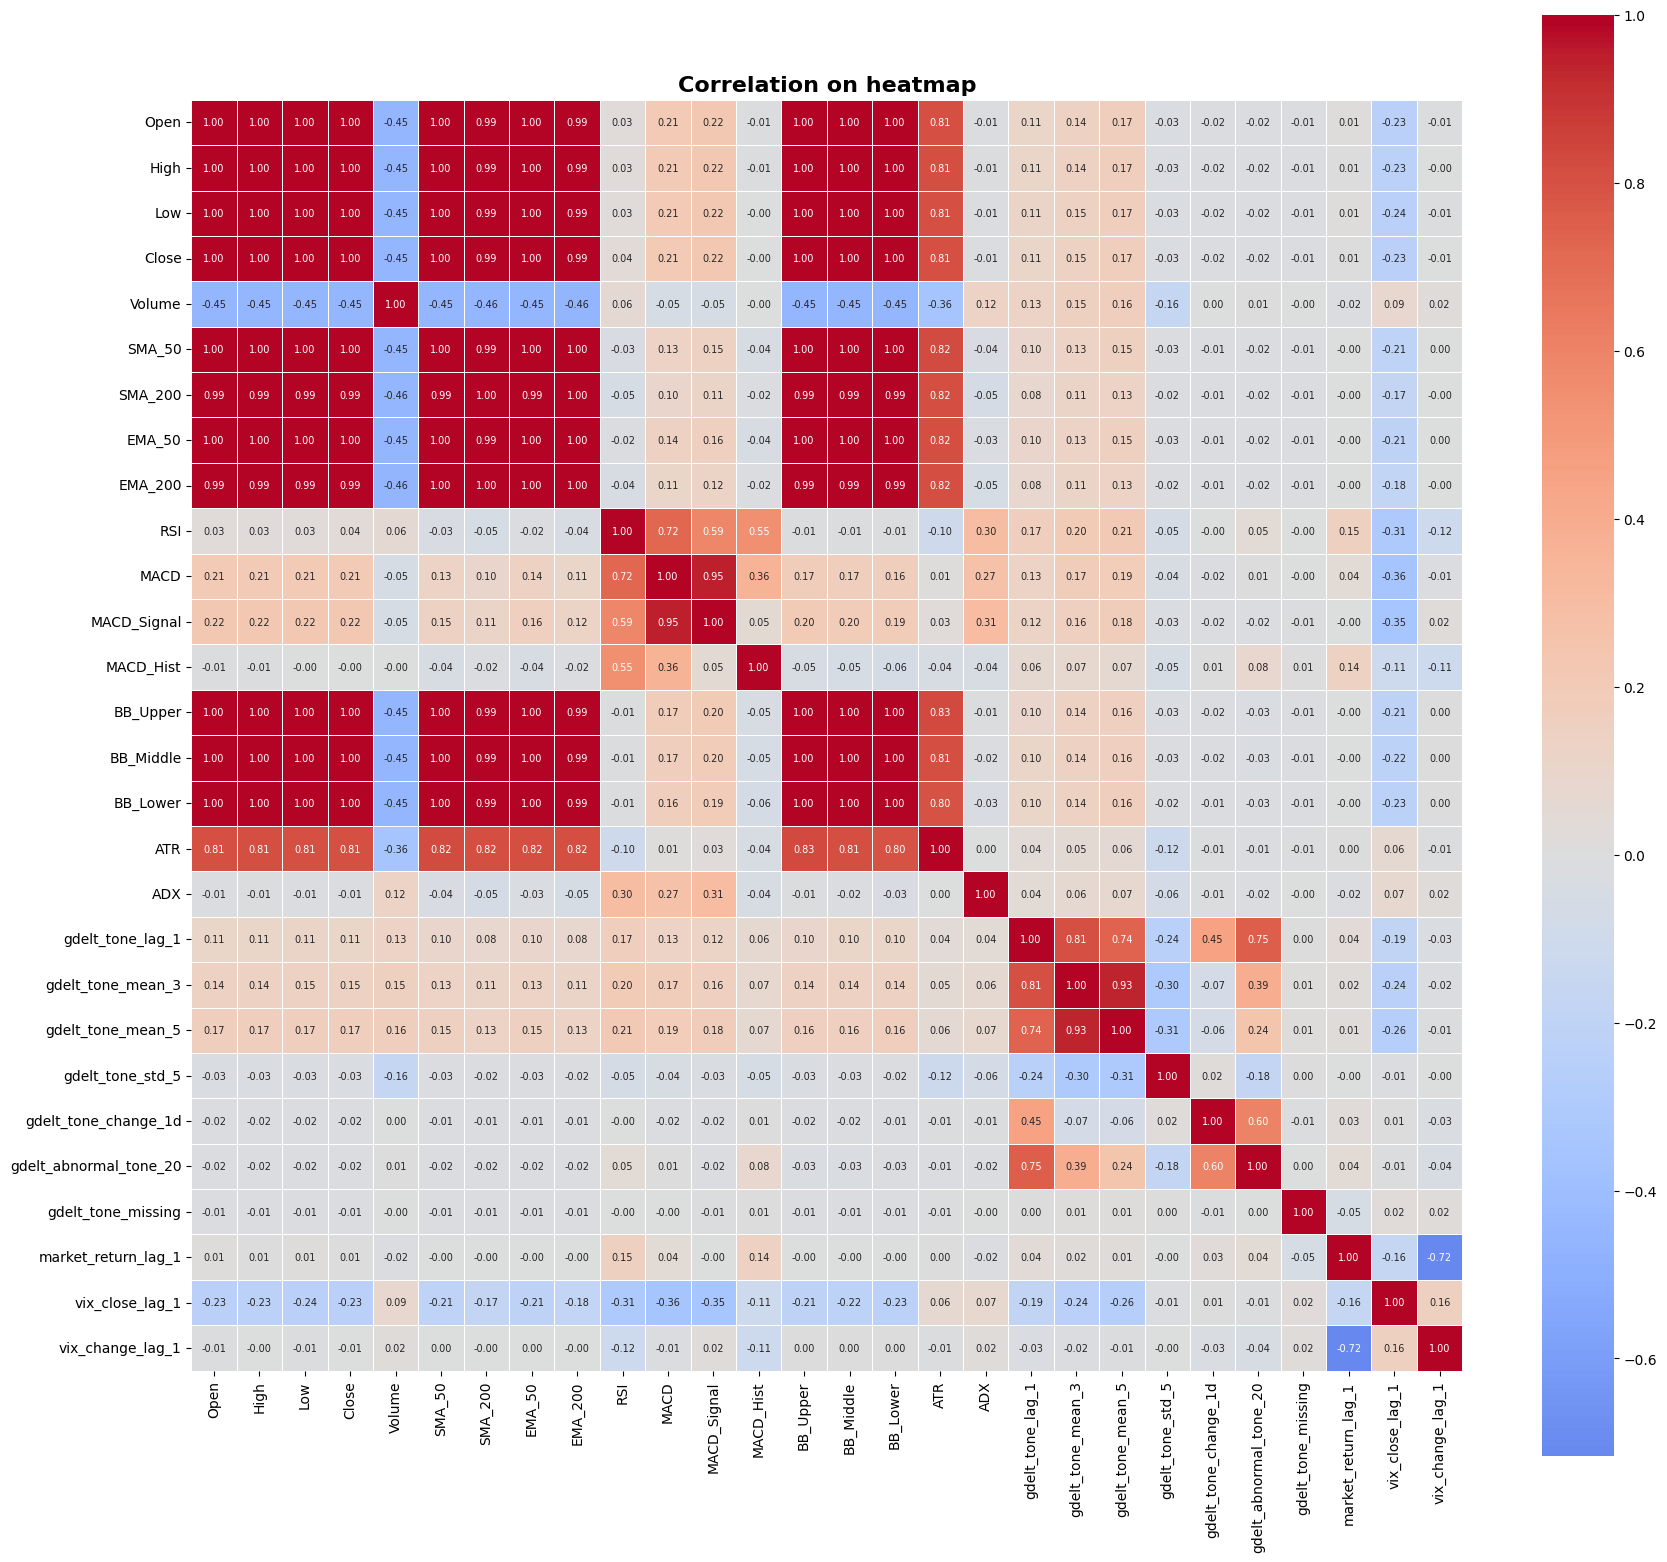

In [23]:
import seaborn as sb
cor1 = df[all_model_features].corr()
plt.figure(figsize=(18,16))
sb.heatmap(cor1, annot = True, cmap='coolwarm', linewidths=0.5, fmt='.2f', center=0, square=True, annot_kws={'size': 7})
plt.title('Correlation on heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Technical Feature Correlations

- The correlations among technical features were examined separately because many indicators are derived from the same underlying price and volume data. 
- Strong correlations are therefore expected, particularly among raw price variables, moving averages, exponential moving averages, and Bollinger Bands.

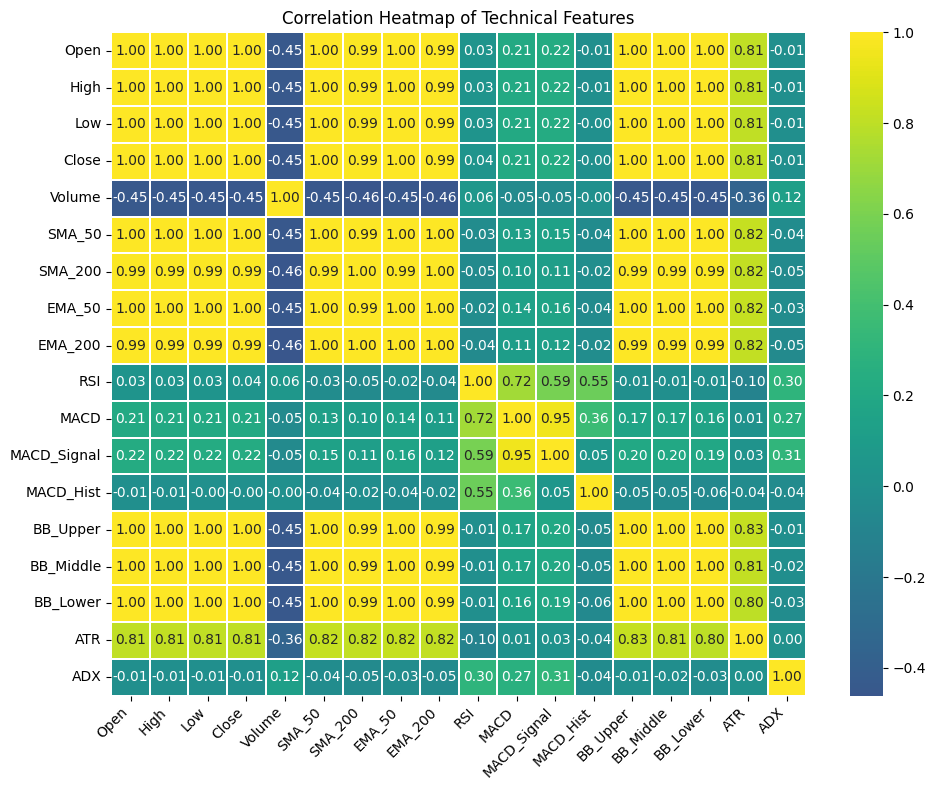

In [24]:
technical_corr = df[technical_features].corr()

plt.figure(figsize=(10, 8))

sb.heatmap(
    technical_corr,
    cmap="viridis",
    center=0,
    annot=True,
    linewidths = 0.05,
    fmt=".2f"
)

plt.title("Correlation Heatmap of Technical Features")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### GDELT Feature Correlations

- The GDELT features were examined separately to understand the relationships among short-term tone, rolling tone summaries, tone variability, abnormal tone, and missingness. 
- Some correlation is expected because several variables are calculated from related rolling windows.

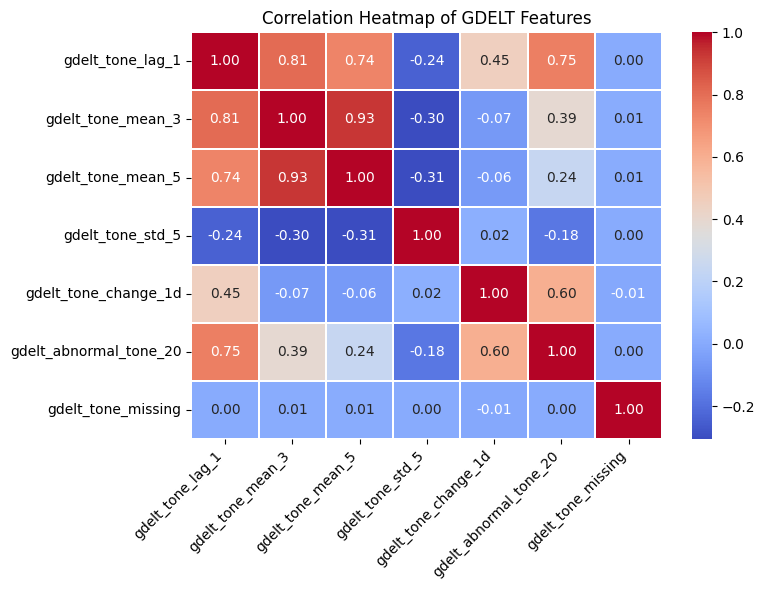

In [25]:
gdelt_corr = df[gdelt_features].corr()
plt.figure(figsize=(8, 6))

sb.heatmap(gdelt_corr, cmap="coolwarm", annot=True, linewidths = 0.05, fmt=".2f")

plt.title("Correlation Heatmap of GDELT Features")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### Market Feature Correlations

- The market-context features were examined separately to assess the relationship between lagged market return, lagged VIX level, and lagged VIX change. 
- These variables represent broader market conditions rather than stock-specific behaviour.

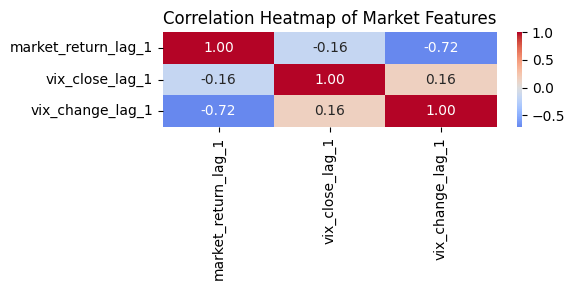

In [26]:
market_corr = df[market_features].corr()

plt.figure(figsize=(6, 3))
sb.heatmap(market_corr, cmap="coolwarm", center=0, annot=True, fmt=".2f")

plt.title("Correlation Heatmap of Market Features")
plt.tight_layout()
plt.show()

### Cross-Group Feature Correlations

- A smaller cross-group heatmap was used to examine whether selected technical, GDELT, and market features capture overlapping or distinct information. 
- Representative features were chosen from each feature group to keep the figure readable.

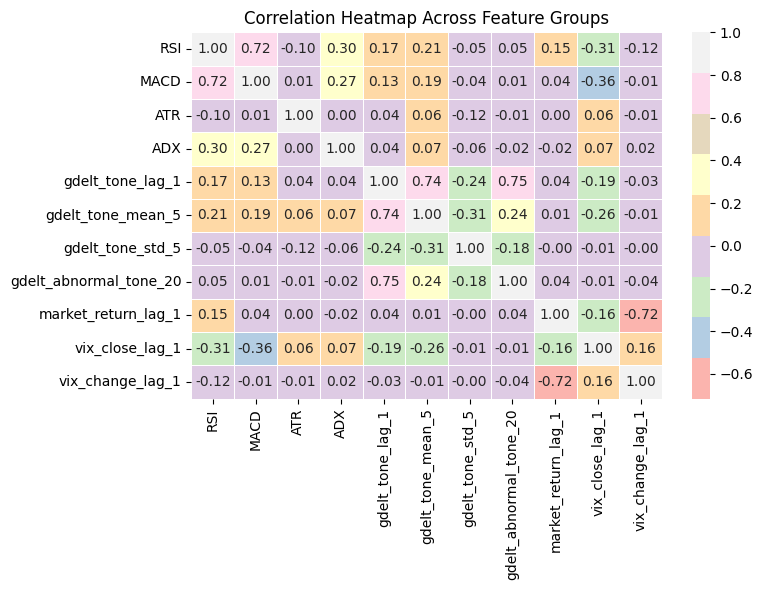

In [27]:
cross_group_features = [
    "RSI",
    "MACD",
    "ATR",
    "ADX",
    "gdelt_tone_lag_1",
    "gdelt_tone_mean_5",
    "gdelt_tone_std_5",
    "gdelt_abnormal_tone_20",
    "market_return_lag_1",
    "vix_close_lag_1",
    "vix_change_lag_1"
]

cross_group_corr = df[cross_group_features].corr()

plt.figure(figsize=(8, 6))

sb.heatmap(
    cross_group_corr,
    cmap="Pastel1",
    linewidth = 0.5,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap Across Feature Groups")
plt.tight_layout()
plt.show()

## Temporal Analysis

Stock-market conditions can change considerably over time. The target distribution was therefore examined by year to determine whether the proportions of Down, Neutral, and Up observations remained stable throughout the study period.

This is important because changes in class distribution may influence model performance across different temporal test periods.

In [28]:
df["year"] = df["date"].dt.year

yearly_target = pd.crosstab( df["year"], df["target_5d"], normalize="index") * 100
yearly_target = yearly_target.rename( columns={ 0: "Down", 1: "Neutral", 2: "Up"})

display(yearly_target.round(2))

target_5d,Down,Neutral,Up
year,,,
2020,33.36,25.08,41.56
2021,24.21,35.95,39.84
2022,37.21,24.14,38.65
2023,20.72,41.37,37.91
2024,25.87,32.78,41.35
2025,24.96,37.52,37.52


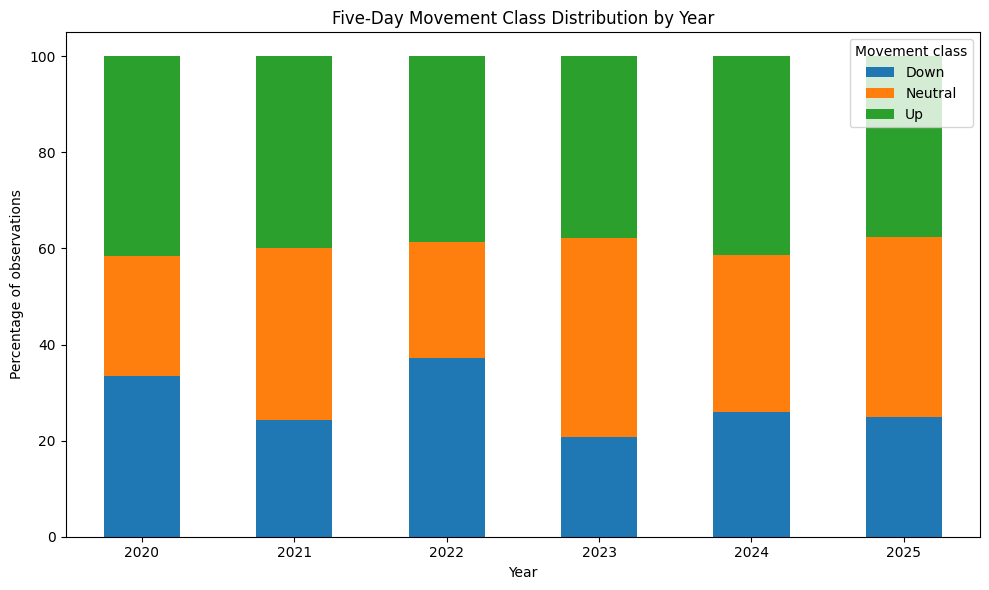

In [29]:
yearly_target.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.ylabel("Percentage of observations")
plt.xlabel("Year")
plt.title("Five-Day Movement Class Distribution by Year")
plt.xticks(rotation=0)
plt.legend(title="Movement class")

plt.tight_layout()
plt.show()

## EDA Conclusions

The exploratory analysis showed that the dataset is complete and suitable for model development. The target distribution varies across stocks and years, supporting stock-specific and temporal evaluation.

Technical features exhibited strong within-group correlations, while GDELT and market features provided complementary information. Most continuous features showed only moderate skewness, with the highly skewed `gdelt_tone_missing` variable behaving as expected for a rare binary indicator.

Overall, the EDA supports proceeding to model training and evaluation.